In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import re, html     # Regular expressions & HTML unescaping
import string      # String constants
import seaborn as sb
import matplotlib.pyplot as plt

In [19]:
# Text Normalization & NLP Libraries
import nltk
from nltk.tokenize import word_tokenize, TweetTokenizer     # Text normalization: Tokenization
from nltk import word_tokenize, pos_tag     # Part-of-Speech tagging
from nltk.stem import WordNetLemmatizer     # Text normalization: Lemmatization
from nltk.corpus import wordnet
from nltk.corpus import stopwords     # Remove stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer     # TF-IDF feature extraction

# Download Required NLTK Resources
nltk.download("punkt")     # Tokenizer models
nltk.download("punkt_tab")     # Additional tokenizer tables
nltk.download('stopwords')     # Stopword list
nltk.download('averaged_perceptron_tagger_eng')     # POS tagger
nltk.download('wordnet')     # Lemmatization resource

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [20]:
#Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold     # Splits data into train and test sets
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC     # Support Vector Machine optimized

# Evaluation Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

In [4]:
train_path = "/content/train.csv"
df = pd.read_csv(train_path)   # Load the dataset
df.head()     # observe 5 first rows

,id,tweet,label
0,86426,@USER She should ask a few native Americans wh...,UNT
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN
2,16820,Amazon is investigating Chinese employees who ...,NOT
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT


<Axes: xlabel='label', ylabel='count'>

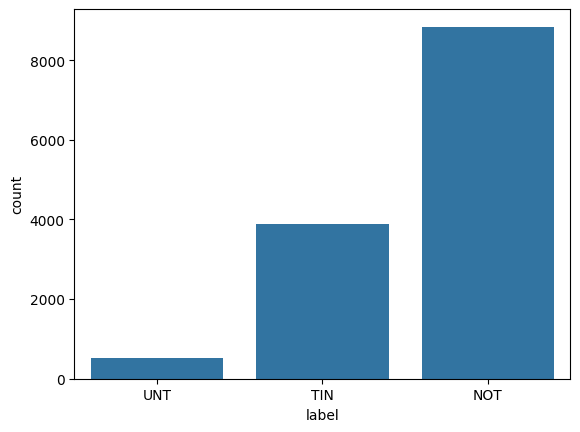

In [5]:
# Summarise class details
sb.countplot(x=df['label'])

In [6]:
print("Shape:", df.shape)
print("\nLabel counts:\n", df["label"].value_counts())

Shape: (13240, 3)

Label counts:
 label
NOT    8840
TIN    3876
UNT     524
Name: count, dtype: int64


###**Data Cleaning**

In [7]:
df.dropna(inplace=True)     # Remove rows that contain any missing (NaN) values
print(f'Number of entries: {len(df)}')

Number of entries: 13240


###**Regex normalization**

In [8]:
# Regex normalization
def normalize_profanity(tweet):
    tweet = re.sub(r"\bbull\s*sh\W*t\b", "bullshit", tweet, flags=re.I)
    tweet = re.sub(r"\bsh\W*t\b", "shit", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*ing\b", "fucking", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\W*s\b", "fucks", tweet, flags=re.I)
    tweet = re.sub(r"\bf\W*u\W*c\W*k\b", "fuck", tweet, flags=re.I)
    tweet = re.sub(r"\bd\W*mbasses\b", "dumbasses", tweet, flags=re.I)
    tweet = re.sub(r"\bc\W*ck\b", "cock", tweet, flags=re.I)
    return tweet

###**Text Tokenisation**

In [9]:
# convert text to tokens
tokenizer = TweetTokenizer(preserve_case=False,
                    strip_handles=True,
                    reduce_len=True
)
for i in range(5):
    tweet = df["tweet"].iloc[i]
    tokens = tokenizer.tokenize(tweet)
    print("Original:", tweet)
    print("Tokens:", tokens)
    print("-" * 50)

Original: @USER She should ask a few native Americans what their take on this is.
Tokens: ['she', 'should', 'ask', 'a', 'few', 'native', 'americans', 'what', 'their', 'take', 'on', 'this', 'is', '.']
--------------------------------------------------
Original: @USER @USER Go home you’re drunk!!! @USER #MAGA #Trump2020 👊🇺🇸👊 URL
Tokens: ['go', 'home', 'you', '’', 're', 'drunk', '!', '!', '!', '#maga', '#trump2020', '👊', '🇺🇸', '👊', 'url']
--------------------------------------------------
Original: Amazon is investigating Chinese employees who are selling internal data to third-party sellers looking for an edge in the competitive marketplace. URL #Amazon #MAGA #KAG #CHINA #TCOT
Tokens: ['amazon', 'is', 'investigating', 'chinese', 'employees', 'who', 'are', 'selling', 'internal', 'data', 'to', 'third-party', 'sellers', 'looking', 'for', 'an', 'edge', 'in', 'the', 'competitive', 'marketplace', '.', 'url', '#amazon', '#maga', '#kag', '#china', '#tcot']
---------------------------------------

In [10]:
# Merge to tokens back into sentences by adding a space between two tokens.
joined_tokens_list = []
for tweet in df["tweet"]:
    tokens = tokenizer.tokenize(tweet)
    joined_tokens = " ".join(tokens)
    joined_tokens_list.append(joined_tokens)

# add new column to data frame
df["tokenized_tweet"] = joined_tokens_list
df.head()

,id,tweet,label,tokenized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to..."
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...


###**Text Lemmatisation**

In [11]:
# Apply POS tags
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [12]:
# Lemmatized with WordNet to reduce inflected forms to their base form
wnl = WordNetLemmatizer()
df["lemmatized_tweet"] = df["tokenized_tweet"].apply(
    lambda tweet_string: " ".join(
        wnl.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in nltk.pos_tag(nltk.word_tokenize(tweet_string))
    )
)
df.head()

,id,tweet,label,tokenized_tweet,lemmatized_tweet
0,86426,@USER She should ask a few native Americans wh...,UNT,she should ask a few native americans what the...,she should ask a few native american what thei...
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN,go home you ’ re drunk ! ! ! #maga #trump2020 ...,go home you ’ re drunk ! ! ! # maga # trump202...
2,16820,Amazon is investigating Chinese employees who ...,NOT,amazon is investigating chinese employees who ...,amazon be investigate chinese employee who be ...
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT,"someone should'vetaken "" this piece of shit to...",someone should'vetaken `` this piece of shit t...
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT,obama wanted liberals & illegals to move into ...,obama want liberal & illegals to move into red...


###**Stop word removal**

In [13]:
# get English stopwords
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Stopword removal is NOT necessarily suitable for this dataset, and in many cases it can hurt performance. Instead, TF-IDF weighting was used to reduce the impact of frequent terms while preserving syntactic structure.

###**Text feature extraction and model generation**

In [14]:
# Define features and labels
X_tweet = df['tweet']
X_tokenized = df['tokenized_tweet']
X_lemmatized = df['lemmatized_tweet']
y = df['label']

In [15]:
# Train / test split
(X_tweet_train, X_tweet_val,
 X_tokenized_train, X_tokenized_val,
 X_lemmatized_train, X_lemmatized_val,
 y_train, y_val) = train_test_split(X_tweet, X_tokenized, X_lemmatized, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
# Sanity check
print("Tweet:", len(X_tweet_train),",", len(X_tweet_val))
print("Tokenized:", len(X_tokenized_train),",", len(X_tokenized_val))
print("Lemmatized:", len(X_lemmatized_train),",", len(X_lemmatized_val))
print("Labels:", len(y_train),",", len(y_val))

Tweet: 9268 , 3972
Tokenized: 9268 , 3972
Lemmatized: 9268 , 3972
Labels: 9268 , 3972


In [17]:
# Evaluation function
def evaluate(actuals, predictions, labels):

    # 1) Accuracy
    accuracy = metrics.accuracy_score(actuals, predictions)
    print(f"Accuracy: {accuracy:.4f}")

    # 2) Precision, Recall, F1 (macro)
    precision = metrics.precision_score(actuals, predictions, average="macro", zero_division=0)
    recall = metrics.recall_score(actuals, predictions, average="macro", zero_division=0)
    f1 = metrics.f1_score(actuals, predictions, average="macro", zero_division=0)

    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro):    {recall:.4f}")
    print(f"F1-score (macro):  {f1:.4f}")

    # 3) Confusion Matrix
    cm = metrics.confusion_matrix(actuals, predictions, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(values_format="d")
    plt.title("Confusion Matrix")
    plt.show()

    # return values
    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
        "confusion_matrix": cm
    }

###**SVM**

In [21]:
# Train an SVM classifier and predict on validation data.
def get_svm_predictions(X_train, X_val, y_train, y_val):
    classifier = LinearSVC(random_state=42, class_weight="balanced", C=1.0)
    classifier.fit(X_train, y_train)

    # make predictions on validation data
    y_pred = classifier.predict(X_val)

    # evaluation
    evaluate(y_val, y_pred, labels=["NOT", "TIN", "UNT"])
    return classifier

###**Models**

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.6981
Precision (macro): 0.4977
Recall (macro):    0.4927
F1-score (macro):  0.4949


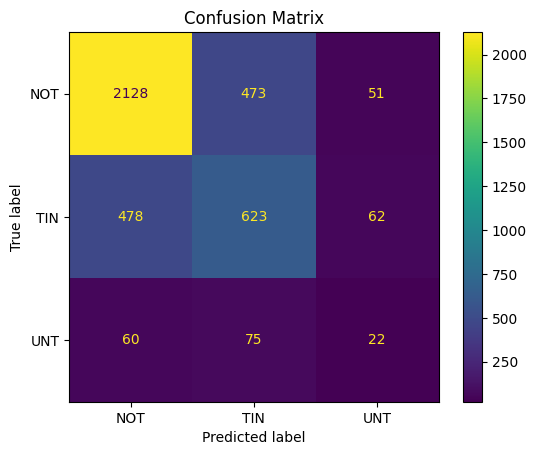

In [22]:
# Model 1 - ngram_range=(1,1)
vectorizer = CountVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m1 = get_svm_predictions(X_train, X_val, y_train, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.7324
Precision (macro): 0.5617
Recall (macro):    0.4882
F1-score (macro):  0.5034


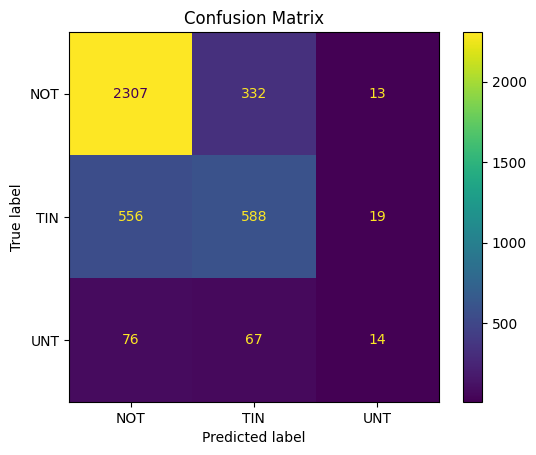

In [23]:
# Model 1 - ngram_range=(1,2)
vectorizer = CountVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m11 = get_svm_predictions(X_train, X_val, y_train, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.6699
Precision (macro): 0.4945
Recall (macro):    0.4066
F1-score (macro):  0.4150


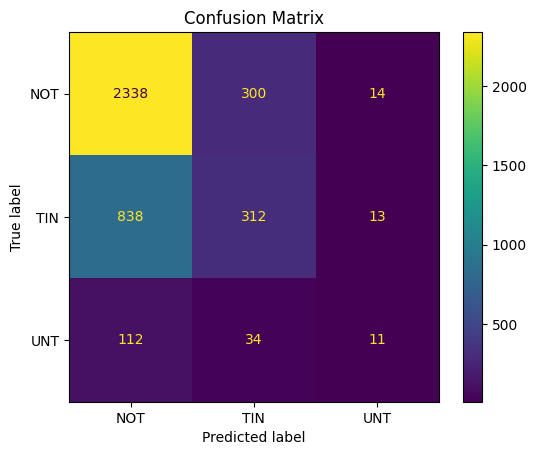

In [24]:
# Model 1 - ngram_range=(2,2)
vectorizer = CountVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m12 = get_svm_predictions(X_train, X_val, y_train, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.7246
Precision (macro): 0.5649
Recall (macro):    0.4677
F1-score (macro):  0.4828


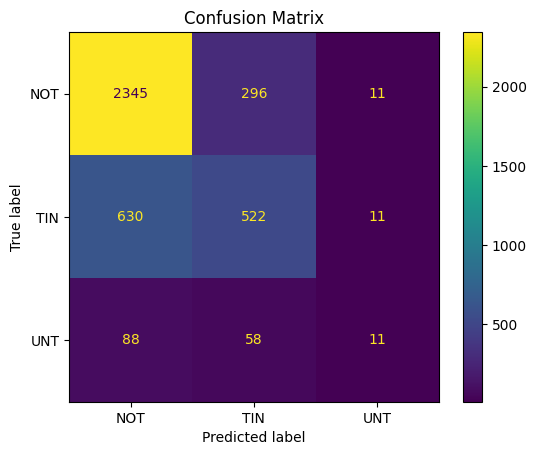

In [25]:
# Model 1 - ngram_range=(1,3)
vectorizer = CountVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m13 = get_svm_predictions(X_train, X_val, y_train, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Accuracy: 0.6745
Precision (macro): 0.4915
Recall (macro):    0.3667
F1-score (macro):  0.3435


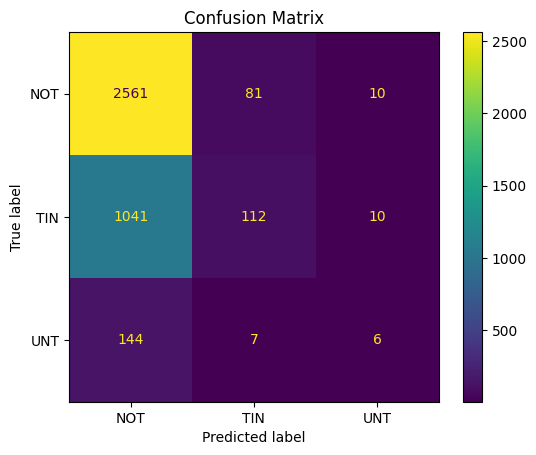

In [26]:
# Model 1 - ngram_range=(3,3)
vectorizer = CountVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m14 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7125
Precision (macro): 0.5062
Recall (macro):    0.4913
F1-score (macro):  0.4970


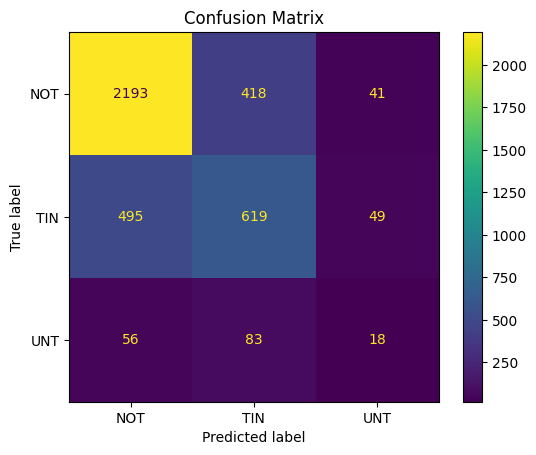

In [27]:
# Model 2 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m2 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7276
Precision (macro): 0.5745
Recall (macro):    0.4843
F1-score (macro):  0.4990


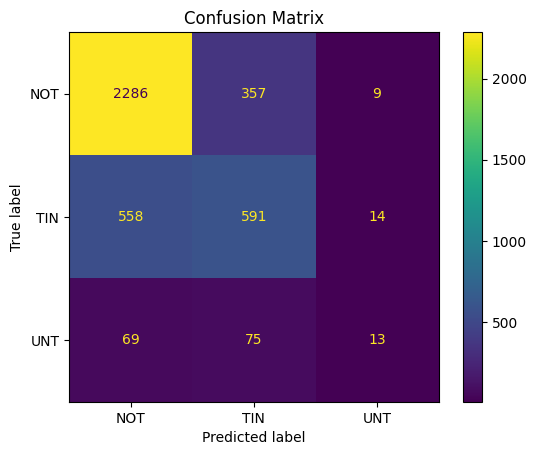

In [28]:
# Model 2 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m21 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6649
Precision (macro): 0.4977
Recall (macro):    0.4074
F1-score (macro):  0.4166


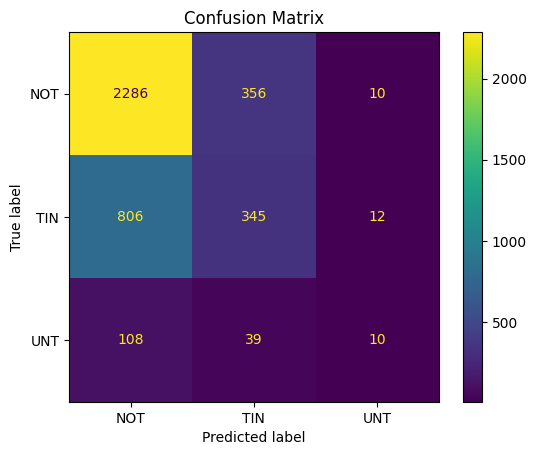

In [29]:
# Model 2 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m22 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7246
Precision (macro): 0.5889
Recall (macro):    0.4773
F1-score (macro):  0.4924


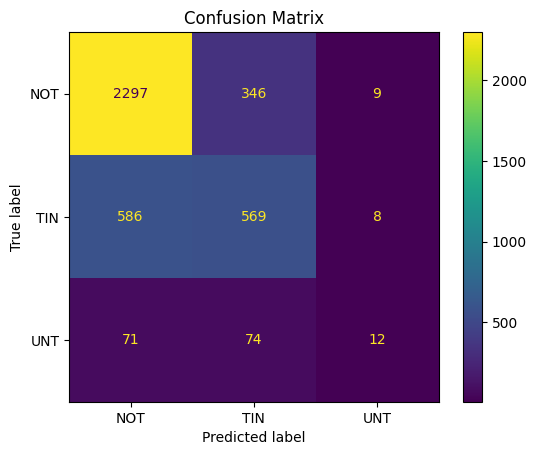

In [30]:
# Model 2 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m23 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6601
Precision (macro): 0.4389
Recall (macro):    0.3665
F1-score (macro):  0.3537


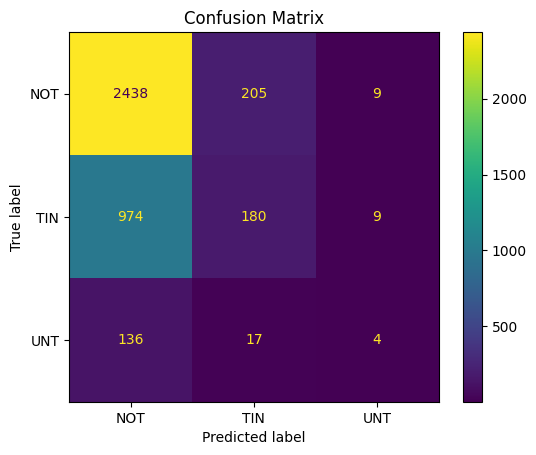

In [31]:
# Model 2 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tweet_train)

X_train = vectorizer.transform(X_tweet_train)
X_val = vectorizer.transform(X_tweet_val)

m24 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7072
Precision (macro): 0.5011
Recall (macro):    0.4875
F1-score (macro):  0.4927


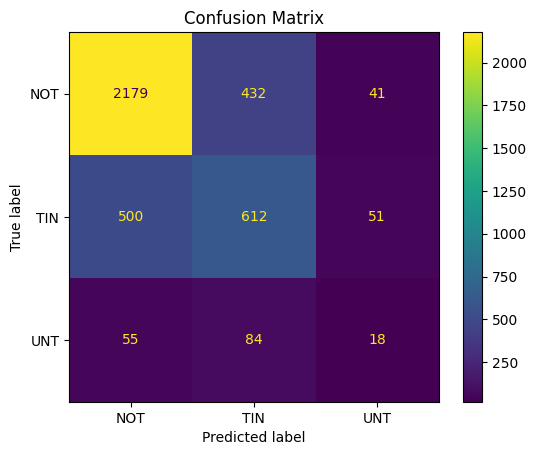

In [32]:
# Model 3 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m3 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7246
Precision (macro): 0.5637
Recall (macro):    0.4901
F1-score (macro):  0.5015


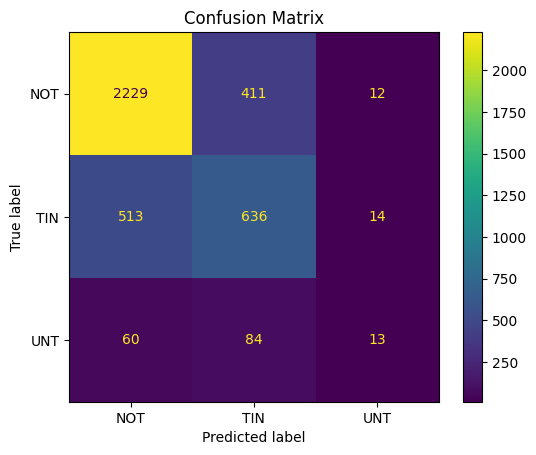

In [33]:
# Model 3 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m31 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6654
Precision (macro): 0.4666
Recall (macro):    0.4016
F1-score (macro):  0.4058


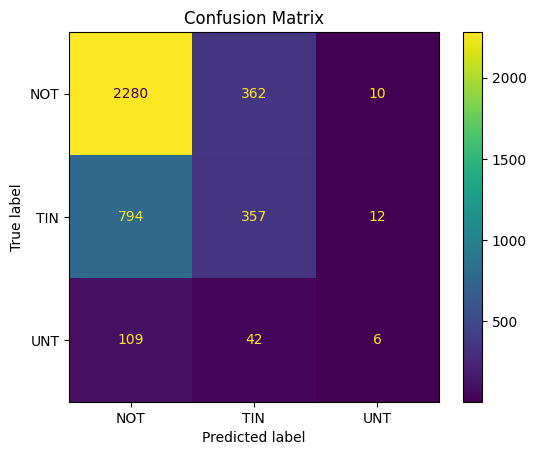

In [34]:
# Model 3 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m32 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7200
Precision (macro): 0.5506
Recall (macro):    0.4830
F1-score (macro):  0.4920


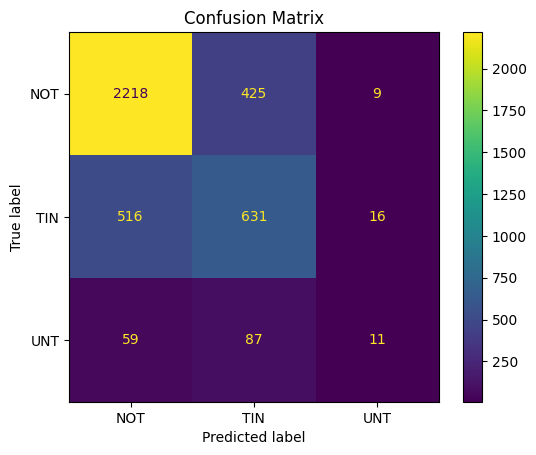

In [35]:
# Model 3 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m33 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6574
Precision (macro): 0.4271
Recall (macro):    0.3558
F1-score (macro):  0.3348


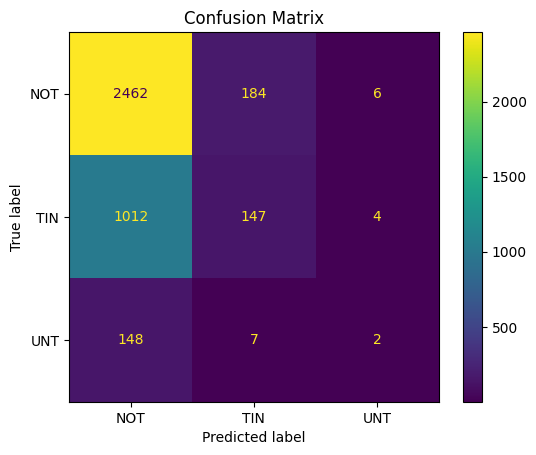

In [36]:
# Model 3 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m34 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7132
Precision (macro): 0.5030
Recall (macro):    0.4920
F1-score (macro):  0.4966


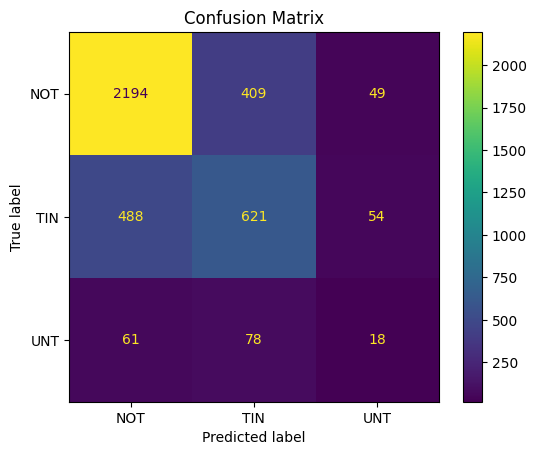

In [37]:
# Model 4 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(ngram_range=(1,1), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m4 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7228
Precision (macro): 0.5335
Recall (macro):    0.4850
F1-score (macro):  0.4929


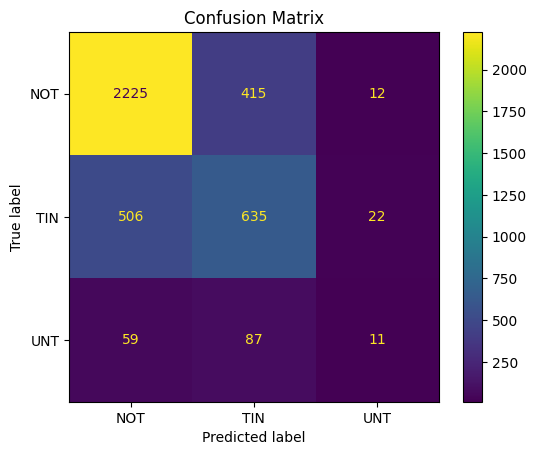

In [38]:
# Model 4 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m41 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6717
Precision (macro): 0.4744
Recall (macro):    0.4098
F1-score (macro):  0.4150


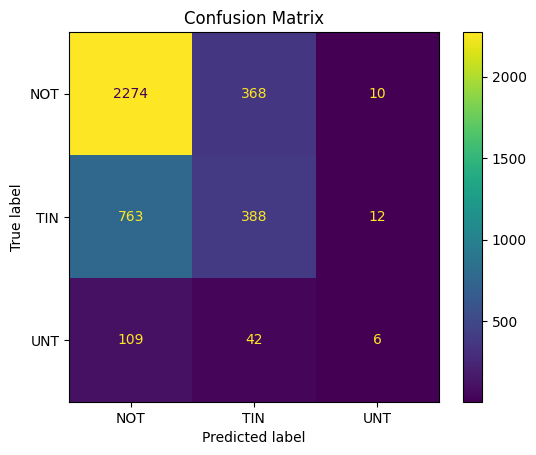

In [39]:
# Model 4 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m42 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7195
Precision (macro): 0.5347
Recall (macro):    0.4843
F1-score (macro):  0.4917


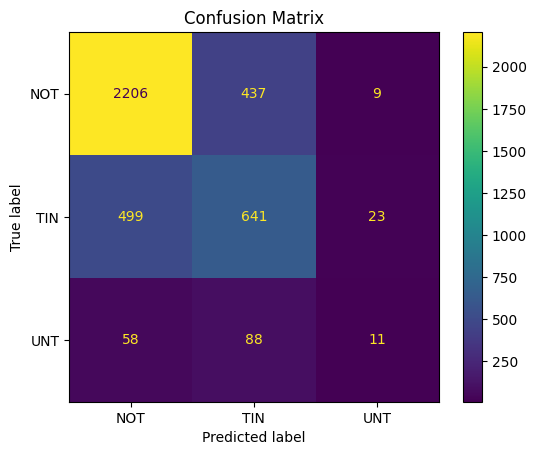

In [40]:
# Model 4 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m43 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6616
Precision (macro): 0.4377
Recall (macro):    0.3611
F1-score (macro):  0.3427


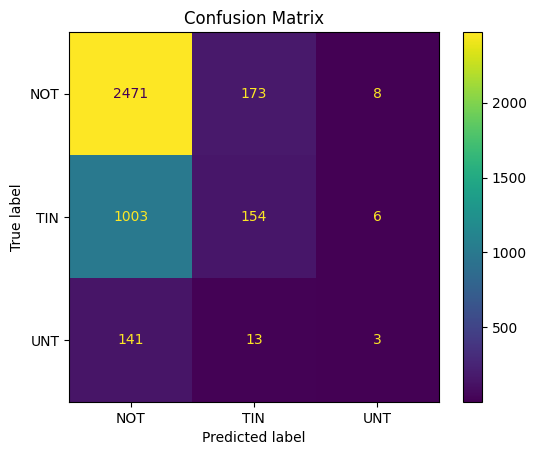

In [41]:
# Model 4 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m44 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7097
Precision (macro): 0.5007
Recall (macro):    0.4896
F1-score (macro):  0.4941


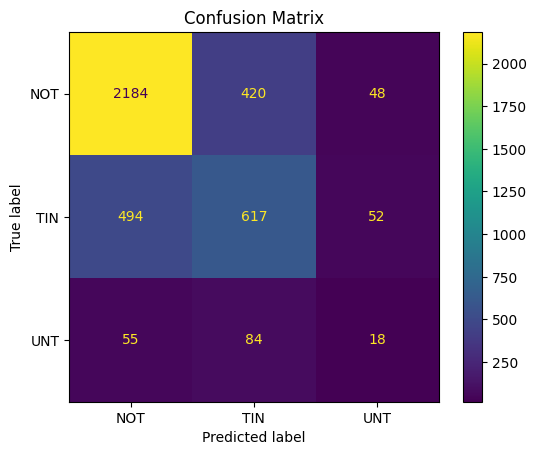

In [42]:
# Model 5 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m5 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7205
Precision (macro): 0.5297
Recall (macro):    0.4872
F1-score (macro):  0.4960


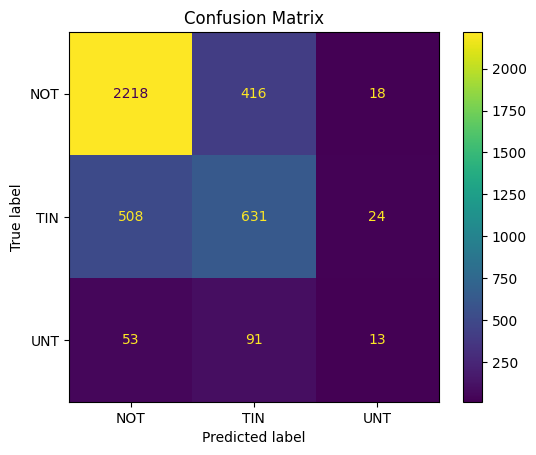

In [43]:
# Model 5 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m51 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6609
Precision (macro): 0.4338
Recall (macro):    0.3718
F1-score (macro):  0.3625


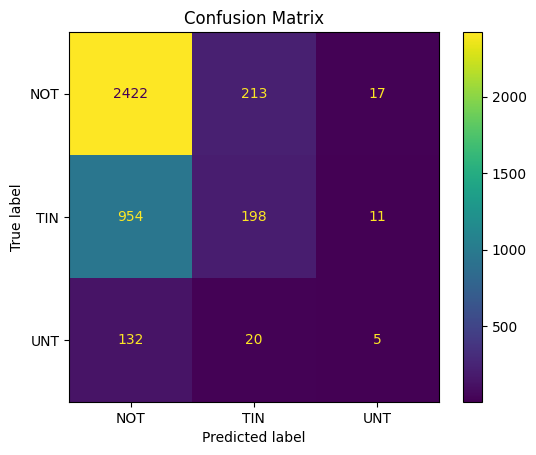

In [44]:
# Model 5 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m52 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7180
Precision (macro): 0.5346
Recall (macro):    0.4841
F1-score (macro):  0.4938


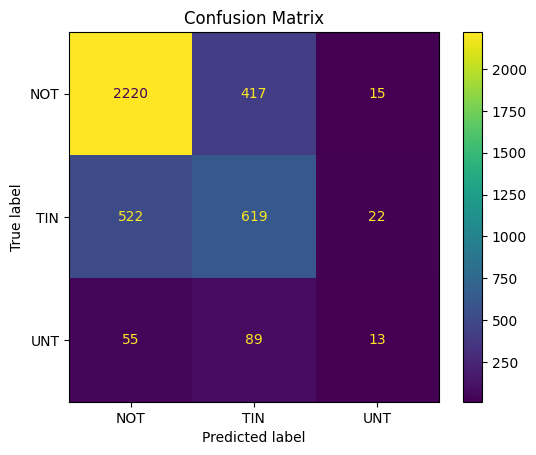

In [45]:
# Model 5 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m53 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6599
Precision (macro): 0.3732
Recall (macro):    0.3347
F1-score (macro):  0.2796


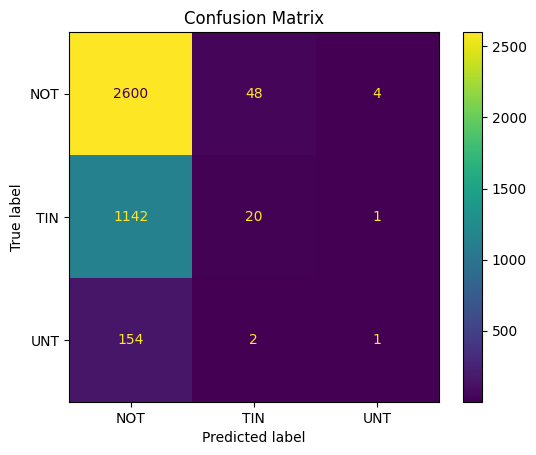

In [46]:
# Model 5 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_tokenized_train)

X_train = vectorizer.transform(X_tokenized_train)
X_val = vectorizer.transform(X_tokenized_val)

m54 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7054
Precision (macro): 0.4988
Recall (macro):    0.4943
F1-score (macro):  0.4964


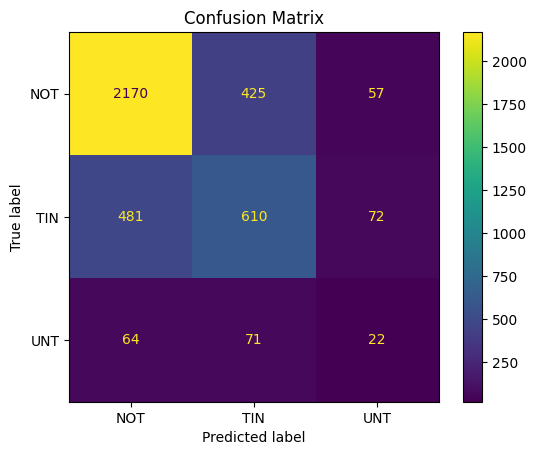

In [47]:
# Model 6 - ngram_range=(1,1)
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, ngram_range=(1,1))
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m6 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7155
Precision (macro): 0.5183
Recall (macro):    0.4852
F1-score (macro):  0.4925


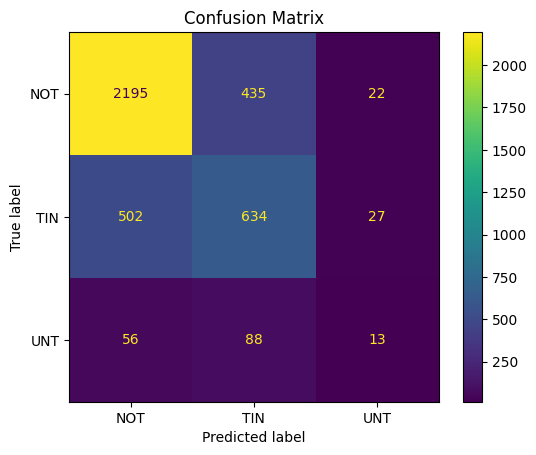

In [48]:
# Model 6 - ngram_range=(1,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m61 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6566
Precision (macro): 0.4231
Recall (macro):    0.3691
F1-score (macro):  0.3598


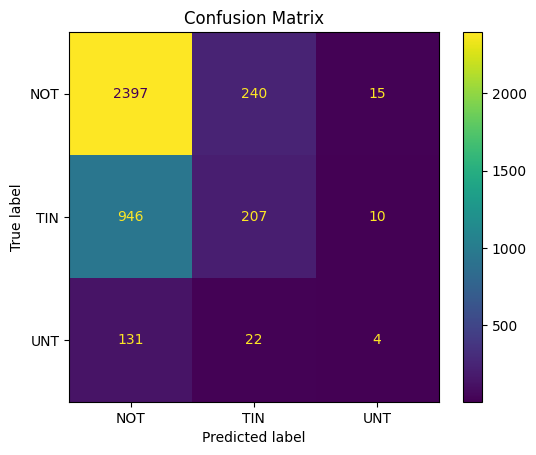

In [49]:
# Model 6 - ngram_range=(2,2)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(2,2), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m62 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.7170
Precision (macro): 0.5290
Recall (macro):    0.4860
F1-score (macro):  0.4945


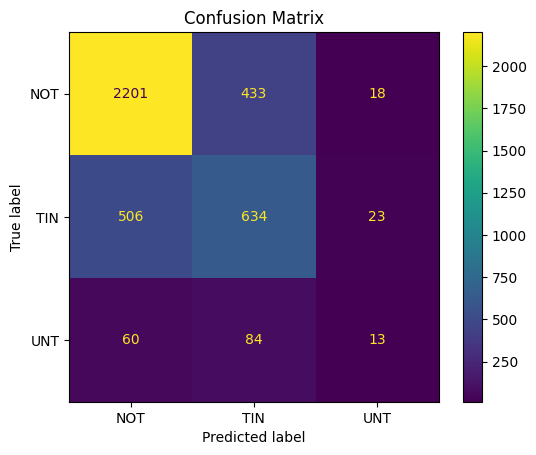

In [50]:
# Model 6 - ngram_range=(1,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(1,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m63 = get_svm_predictions(X_train, X_val, y_train, y_val)

Accuracy: 0.6576
Precision (macro): 0.3725
Recall (macro):    0.3357
F1-score (macro):  0.2835


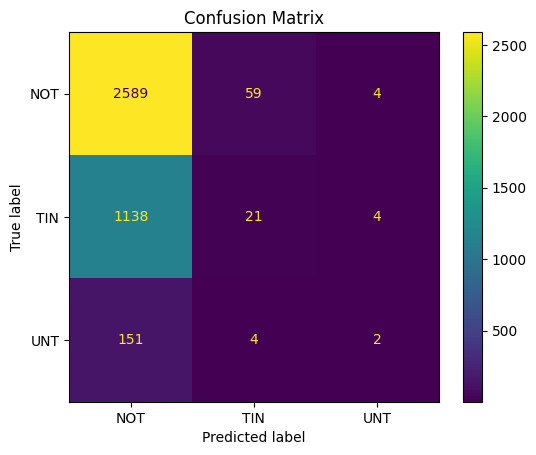

In [51]:
# Model 6 - ngram_range=(3,3)
vectorizer = TfidfVectorizer(stop_words=stop_words, ngram_range=(3,3), lowercase=True)
vectorizer.fit(X_lemmatized_train)

X_train = vectorizer.transform(X_lemmatized_train)
X_val = vectorizer.transform(X_lemmatized_val)

m63 = get_svm_predictions(X_train, X_val, y_train, y_val)

In [52]:
vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(1,3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)
vectorizer.fit(X_lemmatized_train)
X_train_vec = vectorizer.fit_transform(X_tweet_train)
X_val_vec = vectorizer.transform(X_tweet_val)

# Multiple C values for LinearSVC
best = None
for C in [0.1, 1, 3, 10]:
    clf = LinearSVC(C=C, class_weight="balanced", random_state=42)
    clf.fit(X_train_vec, y_train)

    # Predict on validation set
    y_pred = clf.predict(X_val_vec)

    # Evaluate
    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")

    print("C=", C, "acc=", round(acc,4), "macro_f1=", round(macro_f1,4))

C= 0.1 acc= 0.7336 macro_f1= 0.5231
C= 1 acc= 0.7163 macro_f1= 0.5009
C= 3 acc= 0.7029 macro_f1= 0.4968
C= 10 acc= 0.6876 macro_f1= 0.4818


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
